# Tutorial: Gradient Clipping from Basics to `clipped_grad`

**Prerequisites**: Basic PyTorch (tensors, `torch.nn`, optimizers)

---

## Overview

This tutorial teaches **gradient clipping** from first principles, culminating in Opaque's `clipped_grad()` function.

**Learning progression**:
1. Train a simple MLP with **standard PyTorch** (averaged gradients)
2. Understand **why per-sample gradients matter** for gradient clipping
3. Compute per-sample gradients **manually** (naive iterative approach)
4. Use **functional transformations** (`grad` + `vmap`) for efficiency
5. Convert models to **functional form** with `make_functional()`
6. Use Opaque's **`clipped_grad()`** as a convenient wrapper

**What we're NOT covering**:
- Differential privacy (requires noise injection - Stage 2)
- Privacy accounting
- LoRA fine-tuning

---

## Why Gradient Clipping?

Gradient clipping has two main uses:

1. **Training stability**: Prevent exploding gradients in deep networks
2. **Differential privacy**: Bound sensitivity before adding noise (DP-SGD)

Standard PyTorch clips the **total gradient** (averaged across batch). But for differential privacy, we need to clip **each example's gradient individually** before summing. This requires **per-sample gradients**.

---

In [21]:
import time

import matplotlib.pyplot as plt
# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import grad, vmap

from opaque import make_functional, clipped_grad

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.0


---

## Part 1: Standard PyTorch Training

Let's start with a simple **multi-layer perceptron (MLP)** for binary classification.

In [22]:
class SimpleMLP(nn.Module):
  """Simple MLP: input → hidden (64) → hidden (32) → output (1)"""

  def __init__(self, input_dim=10):
    super().__init__()
    self.fc1 = nn.Linear(input_dim, 64)
    self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(32, 1)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return self.fc3(x).squeeze(-1)


# Create model
model = SimpleMLP(input_dim=10)
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Model architecture:
SimpleMLP(
  (fc1): Linear(in_features=10, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 2817


### Generate Training Data

In [23]:
def generate_data(n_samples=200, input_dim=10, seed=42):
  torch.manual_seed(seed)
  X = torch.randn(n_samples, input_dim)
  # Simple classification: positive if first feature > 0
  y = (X[:, 0] > 0).float()
  return X, y


X_train, y_train = generate_data()
print(f"Training data: {X_train.shape}")
print(f"Labels: {y_train.sum().item():.0f} positive, {(~y_train.bool()).sum().item():.0f} negative")

Training data: torch.Size([200, 10])
Labels: 100 positive, 100 negative


### Standard Training with Averaged Gradients

This is standard PyTorch - gradients are **averaged across the batch**:

In [24]:
# Take a small batch
X_batch = X_train[:4]
y_batch = y_train[:4]

# Standard backward pass
model.zero_grad()
logits = model(X_batch)
loss = F.binary_cross_entropy_with_logits(logits, y_batch)
loss.backward()

print("Standard gradients (averaged across batch):")
for name, param in model.named_parameters():
  print(f"  {name}: shape {param.grad.shape}, L2 norm {param.grad.norm().item():.4f}")

Standard gradients (averaged across batch):
  fc1.weight: shape torch.Size([64, 10]), L2 norm 0.1098
  fc1.bias: shape torch.Size([64]), L2 norm 0.0280
  fc2.weight: shape torch.Size([32, 64]), L2 norm 0.3038
  fc2.bias: shape torch.Size([32]), L2 norm 0.0992
  fc3.weight: shape torch.Size([1, 32]), L2 norm 0.2233
  fc3.bias: shape torch.Size([1]), L2 norm 0.2533


**Key observation**: Each gradient has shape `param.shape`, **not** `(batch_size, *param.shape)`. PyTorch averages gradients across examples.

---

## Part 2: Per-Sample Gradients (Naive Approach)

For gradient clipping in DP-SGD, we need **individual gradients for each example**.

### Why Per-Sample Gradients?

**Problem**: If we clip the averaged gradient, one outlier example with large gradient can dominate:

```
Example 1: gradient norm = 0.1
Example 2: gradient norm = 0.2
Example 3: gradient norm = 10.0  ← OUTLIER!

Averaged gradient norm ≈ 3.4 (dominated by outlier)

If we clip at norm=1.0:
  ❌ Averaged approach: clips to 1.0, but outlier still contributes ~30% of signal
  ✅ Per-sample approach: clip each to 1.0, then sum → outlier contributes only 33%
```

### Naive Implementation: Loop Over Examples

In [25]:
def per_sample_gradients_naive(model, X_batch, y_batch):
  """
  Compute per-sample gradients by looping over examples.

  Returns:
      List of dicts, one per example, each containing gradients for all parameters
  """
  per_sample_grads = []

  for i in range(len(X_batch)):
    # Forward pass for single example
    model.zero_grad()
    logit = model(X_batch[i: i + 1])  # Keep batch dimension
    loss = F.binary_cross_entropy_with_logits(logit, y_batch[i: i + 1])

    # Backward pass
    loss.backward()

    # Store gradients for this example
    grads = {name: param.grad.clone() for name, param in model.named_parameters()}
    per_sample_grads.append(grads)

  return per_sample_grads


# Compute per-sample gradients
per_sample_grads = per_sample_gradients_naive(model, X_batch, y_batch)

print(f"Computed gradients for {len(per_sample_grads)} examples\n")
print("Example 0 gradients:")
for n, g in per_sample_grads[0].items():
  print(f"  {n}: shape {g.shape}, L2 norm {g.norm().item():.4f}")

Computed gradients for 4 examples

Example 0 gradients:
  fc1.weight: shape torch.Size([64, 10]), L2 norm 0.3048
  fc1.bias: shape torch.Size([64]), L2 norm 0.0699
  fc2.weight: shape torch.Size([32, 64]), L2 norm 0.9198
  fc2.bias: shape torch.Size([32]), L2 norm 0.1871
  fc3.weight: shape torch.Size([1, 32]), L2 norm 0.6076
  fc3.bias: shape torch.Size([1]), L2 norm 0.4867


### Computing Gradient Norms Per Example

In [26]:
def compute_gradient_norm(grad_dict):
  """Compute L2 norm of all gradients in a dict."""
  return torch.sqrt(sum((g ** 2).sum() for g in grad_dict.values()))


# Compute norms for each example
norms = [compute_gradient_norm(g) for g in per_sample_grads]

print("Per-example gradient norms:")
for i, norm in enumerate(norms):
  print(f"  Example {i}: {norm.item():.4f}")

print(f"\nMean: {torch.tensor(norms).mean().item():.4f}")
print(f"Max:  {torch.tensor(norms).max().item():.4f}")
print(f"Min:  {torch.tensor(norms).min().item():.4f}")

Per-example gradient norms:
  Example 0: 1.2589
  Example 1: 0.8493
  Example 2: 0.8978
  Example 3: 0.8200

Mean: 0.9565
Max:  1.2589
Min:  0.8200


**Problem with naive approach**:
- ⏱️ **Slow**: Loops are inefficient (no parallelization)
- 🔄 **Redundant**: Computes same forward pass multiple times
- 💾 **Memory**: Stores full computation graph for each example

For a batch of 32, we do **32 separate backward passes**!

---

## Part 3: Functional Approach with `grad` and `vmap`

PyTorch's `torch.func` provides **functional transformations** to compute per-sample gradients efficiently.

### Key Concepts

1. **`grad(f)`**: Returns a function that computes gradients of `f`
2. **`vmap(f)`**: Vectorizes `f` over a batch dimension (like NumPy's `vmap`)
3. **Functional models**: Pass parameters as arguments (no internal state)

### Step 1: Convert Model to Functional Form

Opaque provides `make_functional()` to convert any `nn.Module`:

In [27]:
# Create fresh model
model_func = SimpleMLP(input_dim=10)

# Convert to functional form
fmodel, params = make_functional(model_func)

print(f"Functional model: {type(fmodel)}")
print(f"Parameters: tuple of {len(params)} tensors\n")

for i, p in enumerate(params):
  print(f"  params[{i}]: shape {p.shape}")

# Test: call with external parameters
x_test = torch.randn(3, 10)
output = fmodel(params, x_test)
print(f"\nFunctional forward: input {x_test.shape} → output {output.shape}")

Functional model: <class 'function'>
Parameters: tuple of 6 tensors

  params[0]: shape torch.Size([64, 10])
  params[1]: shape torch.Size([64])
  params[2]: shape torch.Size([32, 64])
  params[3]: shape torch.Size([32])
  params[4]: shape torch.Size([1, 32])
  params[5]: shape torch.Size([1])

Functional forward: input torch.Size([3, 10]) → output torch.Size([3])


### Step 2: Define a Per-Example Loss Function

In [28]:
def loss_single(params, x, y):
  """
  Loss for a SINGLE example.

  Args:
      params: Model parameters (tuple of tensors)
      x: Single input (shape: [input_dim])
      y: Single label (scalar)

  Returns:
      Scalar loss
  """
  # Add batch dimension for model
  logit = fmodel(params, x.unsqueeze(0))
  return F.binary_cross_entropy_with_logits(logit.squeeze(), y)


# Test on single example
loss_value = loss_single(params, X_batch[0], y_batch[0])
print(f"Single example loss: {loss_value.item():.4f}")

Single example loss: 0.6592


### Step 3: Compute Gradient with `grad()`

`grad(f)` returns a function that computes gradients of `f` w.r.t. its first argument:

In [29]:
# Create gradient function
grad_fn = grad(loss_single)  # Differentiates w.r.t. first arg (params)

# Compute gradient for one example
grad_single = grad_fn(params, X_batch[0], y_batch[0])

print("Gradient for single example (using grad):")
print(f"  Type: {type(grad_single)}")
print(f"  Number of tensors: {len(grad_single)}")
for i, g in enumerate(grad_single):
  print(f"  grad[{i}]: shape {g.shape}, L2 norm {g.norm().item():.4f}")

Gradient for single example (using grad):
  Type: <class 'tuple'>
  Number of tensors: 6
  grad[0]: shape torch.Size([64, 10]), L2 norm 0.3081
  grad[1]: shape torch.Size([64]), L2 norm 0.0706
  grad[2]: shape torch.Size([32, 64]), L2 norm 0.7660
  grad[3]: shape torch.Size([32]), L2 norm 0.1930
  grad[4]: shape torch.Size([1, 32]), L2 norm 0.5714
  grad[5]: shape torch.Size([1]), L2 norm 0.4827


### Step 4: Vectorize with `vmap()`

`vmap()` automatically vectorizes a function over batch dimensions:

In [30]:
# Create vectorized gradient function
# in_dims=(None, 0, 0) means:
#   - params: don't vectorize (same for all examples)
#   - x: vectorize over dimension 0 (batch)
#   - y: vectorize over dimension 0 (batch)
per_sample_grad_fn = vmap(grad_fn, in_dims=(None, 0, 0))

# Compute per-sample gradients for entire batch
per_sample_grads_vmap = per_sample_grad_fn(params, X_batch, y_batch)

print("Per-sample gradients (using vmap):")
print(f"  Type: {type(per_sample_grads_vmap)}")
print(f"  Number of parameter groups: {len(per_sample_grads_vmap)}\n")

for i, g in enumerate(per_sample_grads_vmap):
  print(f"  grad[{i}]: shape {g.shape}")
  print(f"    → (batch_size, *param_shape) = ({g.shape[0]}, {g.shape[1:]})")

Per-sample gradients (using vmap):
  Type: <class 'tuple'>
  Number of parameter groups: 6

  grad[0]: shape torch.Size([4, 64, 10])
    → (batch_size, *param_shape) = (4, torch.Size([64, 10]))
  grad[1]: shape torch.Size([4, 64])
    → (batch_size, *param_shape) = (4, torch.Size([64]))
  grad[2]: shape torch.Size([4, 32, 64])
    → (batch_size, *param_shape) = (4, torch.Size([32, 64]))
  grad[3]: shape torch.Size([4, 32])
    → (batch_size, *param_shape) = (4, torch.Size([32]))
  grad[4]: shape torch.Size([4, 1, 32])
    → (batch_size, *param_shape) = (4, torch.Size([1, 32]))
  grad[5]: shape torch.Size([4, 1])
    → (batch_size, *param_shape) = (4, torch.Size([1]))


**Key insight**: `vmap` adds a batch dimension to the output!

- Input params: `(param_shape,)`
- Output grads: `(batch_size, *param_shape)`

### Step 5: Verify Equivalence with Naive Approach

In [31]:
# IMPORTANT: For fair comparison, compute naive gradients using model_func
# (not the original model from Part 1)
per_sample_grads_naive_func = per_sample_gradients_naive(model_func, X_batch, y_batch)

# Compare naive loop vs vmap for first example
naive_grad_0 = per_sample_grads_naive_func[0]
vmap_grad_0 = tuple(g[0] for g in per_sample_grads_vmap)

print("Comparing naive vs vmap for example 0 (same model):\n")
param_names = list(naive_grad_0.keys())

for i, name in enumerate(param_names):
  naive_g = naive_grad_0[name]
  vmap_g = vmap_grad_0[i]
  match = torch.allclose(naive_g, vmap_g, atol=1e-5)
  diff = (naive_g - vmap_g).abs().max().item()
  print(f"  {name}: {'✓ Match' if match else '✗ Mismatch'} (max diff: {diff:.2e})")

print("\n✅ Both methods produce identical gradients!")

Comparing naive vs vmap for example 0 (same model):

  fc1.weight: ✓ Match (max diff: 7.45e-09)
  fc1.bias: ✓ Match (max diff: 3.73e-09)
  fc2.weight: ✓ Match (max diff: 2.24e-08)
  fc2.bias: ✓ Match (max diff: 7.45e-09)
  fc3.weight: ✓ Match (max diff: 5.96e-08)
  fc3.bias: ✓ Match (max diff: 2.98e-08)

✅ Both methods produce identical gradients!


### Performance Comparison: Naive vs Vmap

In [32]:
# Larger batch for timing
X_large = X_train[:64]
y_large = y_train[:64]

# Time naive approach
start = time.time()
per_sample_gradients_naive(model, X_large, y_large)
time_naive = time.time() - start

# Time vmap approach
start = time.time()
per_sample_grad_fn(params, X_large, y_large)
time_vmap = time.time() - start

print(f"Batch size: {len(X_large)}\n")
print(f"Naive loop:  {time_naive * 1000:.2f} ms")
print(f"Vmap:        {time_vmap * 1000:.2f} ms")
print(f"\nSpeedup: {time_naive / time_vmap:.1f}x faster! 🚀")

Batch size: 64

Naive loop:  7.00 ms
Vmap:        0.94 ms

Speedup: 7.5x faster! 🚀


**Why is vmap faster?**
- **Parallelization**: Processes all examples simultaneously
- **Optimized kernels**: Uses efficient batched operations
- **Single computation graph**: No redundant forward passes

---

## Part 4: Gradient Clipping with Manual Implementation

Now let's **clip** per-sample gradients before summing them.

In [33]:
def clip_per_sample_gradients(per_sample_grads, max_norm=1.0):
  """
  Clip per-sample gradients to maximum L2 norm.

  Args:
      per_sample_grads: Tuple of tensors with shape (batch_size, *param_shape)
      max_norm: Maximum L2 norm for each example's gradient

  Returns:
      Clipped gradients (same structure)
  """
  batch_size = per_sample_grads[0].shape[0]
  clipped = []

  for i in range(batch_size):
    # Extract gradient for example i
    grad_i = tuple(g[i] for g in per_sample_grads)

    # Compute L2 norm
    norm = torch.sqrt(sum((g ** 2).sum() for g in grad_i))

    # Clip if necessary
    if norm > max_norm:
      scale = max_norm / norm
      grad_i = tuple(g * scale for g in grad_i)

    clipped.append(grad_i)

  # Restack: list of tuples → tuple of batched tensors
  return tuple(
    torch.stack([clipped[i][j] for i in range(batch_size)])
    for j in range(len(per_sample_grads))
  )


# Compute and clip per-sample gradients
per_sample_grads_vmap = per_sample_grad_fn(params, X_batch, y_batch)
clipped_grads = clip_per_sample_gradients(per_sample_grads_vmap, max_norm=1.0)

print("Clipped per-sample gradients:\n")
for i, g in enumerate(clipped_grads):
  print(f"  grad[{i}]: shape {g.shape}")

# Verify clipping worked
print("\nPer-example norms after clipping:")
for i in range(len(X_batch)):
  grad_i = tuple(g[i] for g in clipped_grads)
  norm = torch.sqrt(sum((g ** 2).sum() for g in grad_i))
  print(f"  Example {i}: {norm.item():.4f} (max allowed: 1.0)")

Clipped per-sample gradients:

  grad[0]: shape torch.Size([4, 64, 10])
  grad[1]: shape torch.Size([4, 64])
  grad[2]: shape torch.Size([4, 32, 64])
  grad[3]: shape torch.Size([4, 32])
  grad[4]: shape torch.Size([4, 1, 32])
  grad[5]: shape torch.Size([4, 1])

Per-example norms after clipping:
  Example 0: 1.0000 (max allowed: 1.0)
  Example 1: 0.9876 (max allowed: 1.0)
  Example 2: 1.0000 (max allowed: 1.0)
  Example 3: 0.9690 (max allowed: 1.0)


### Sum Clipped Gradients

In [34]:
# Sum over batch dimension
summed_grads = tuple(g.sum(dim=0) for g in clipped_grads)

print("Summed clipped gradients:\n")
for i, g in enumerate(summed_grads):
  print(f"  grad[{i}]: shape {g.shape}, L2 norm {g.norm().item():.4f}")

total_norm = torch.sqrt(sum((g ** 2).sum() for g in summed_grads))
print(f"\nTotal gradient norm: {total_norm.item():.4f}")

Summed clipped gradients:

  grad[0]: shape torch.Size([64, 10]), L2 norm 0.5058
  grad[1]: shape torch.Size([64]), L2 norm 0.1542
  grad[2]: shape torch.Size([32, 64]), L2 norm 1.3149
  grad[3]: shape torch.Size([32]), L2 norm 0.4261
  grad[4]: shape torch.Size([1, 32]), L2 norm 1.0813
  grad[5]: shape torch.Size([1]), L2 norm 1.2228

Total gradient norm: 2.2033


**Summary**: We've manually implemented gradient clipping:
1. Compute per-sample gradients (`grad` + `vmap`)
2. Clip each to max norm
3. Sum across batch

But this is **tedious and error-prone**. Let's use Opaque's convenience function!

---

## Part 5: Using Opaque's `clipped_grad()`

Opaque's `clipped_grad()` wraps everything we just did into **one simple function**.

In [35]:
# Define per-example loss
def loss_fn(params, example):
  """Loss for a single example.

  Args:
      params: Model parameters
      example: Tuple of (x, y) for one example

  Note:
      With keep_batch_dim=True (default), x will have shape [1, input_dim]
      and y will have shape [1], so we don't need unsqueeze/squeeze.
  """
  x, y = example
  # x already has batch dim of size 1: shape [1, 10]
  # y already has batch dim of size 1: shape [1]
  logit = fmodel(params, x)  # Output shape: [1]
  return F.binary_cross_entropy_with_logits(logit, y)


# Create clipped gradient function (returns function + state)
clipped_grad_fn, clip_state = clipped_grad(
  loss_fn,
  argnums=0,  # Differentiate w.r.t. first arg (params)
  batch_argnums=1,  # Second arg (example) is batched
  l2_clip_norm=1.0,  # Clip each example to max norm 1.0
)

print(f"Created clipped_grad function!")
print(f"Type: {type(clipped_grad_fn)}")
print(f"Sensitivity bound: {clip_state.sensitivity()}")

Created clipped_grad function!
Type: <class 'opaque.clipping.BoundedSensitivityCallable'>
Sensitivity bound: 1.0


### Compute Clipped Gradients in One Call

In [36]:
# Prepare batch data as tuple
batch_data = (X_batch, y_batch)

# Compute clipped and summed gradients (state= required)
clipped_summed_grads, clip_state = clipped_grad_fn(params, batch_data, state=clip_state)

print("Clipped gradients from clipped_grad():\n")
for i, g in enumerate(clipped_summed_grads):
  print(f"  grad[{i}]: shape {g.shape}, L2 norm {g.norm().item():.4f}")

total_norm = torch.sqrt(sum((g ** 2).sum() for g in clipped_summed_grads))
print(f"\nTotal gradient norm: {total_norm.item():.4f}")

Clipped gradients from clipped_grad():

  grad[0]: shape torch.Size([64, 10]), L2 norm 0.5058
  grad[1]: shape torch.Size([64]), L2 norm 0.1542
  grad[2]: shape torch.Size([32, 64]), L2 norm 1.3149
  grad[3]: shape torch.Size([32]), L2 norm 0.4261
  grad[4]: shape torch.Size([1, 32]), L2 norm 1.0813
  grad[5]: shape torch.Size([1]), L2 norm 1.2228

Total gradient norm: 2.2033


### Verify Equivalence with Manual Implementation

In [37]:
print("Comparing manual vs clipped_grad():")
for i, (manual_g, auto_g) in enumerate(zip(summed_grads, clipped_summed_grads)):
  match = torch.allclose(manual_g, auto_g, atol=1e-5)
  print(f"  grad[{i}]: {'✓ Match' if match else '✗ Mismatch'}")

print("\n✅ Identical results! But much cleaner code.")

Comparing manual vs clipped_grad():
  grad[0]: ✓ Match
  grad[1]: ✓ Match
  grad[2]: ✓ Match
  grad[3]: ✓ Match
  grad[4]: ✓ Match
  grad[5]: ✓ Match

✅ Identical results! But much cleaner code.


---

## Part 6: Training with Clipped Gradients

Let's integrate `clipped_grad()` into a **full training loop**.

In [38]:
def train_with_clipped_grad(model, X, y, n_epochs=20, batch_size=32, lr=0.01, clip_norm=1.0):
  """Training loop with clipped gradients."""
  # Convert to functional
  fmodel, params = make_functional(model)

  # Define loss
  def loss_single(p, ex):
    x, y = ex
    # With keep_batch_dim=True, x has shape [1, 10] and y has shape [1]
    logit = fmodel(p, x)  # Output shape: [1]
    return F.binary_cross_entropy_with_logits(logit, y)

  # Create clipped gradient function
  clipped_grad_fn = clipped_grad(
    loss_single,
    argnums=0,
    batch_argnums=1,
    l2_clip_norm=clip_norm,
    normalize_by=batch_size,  # Divide by batch size (like averaging)
  )

  params = list(params)
  losses = []

  for epoch in range(n_epochs):
    indices = torch.randperm(len(X))
    epoch_loss = 0.0

    for i in range(0, len(X), batch_size):
      batch_indices = indices[i: i + batch_size]
      X_batch = X[batch_indices]
      y_batch = y[batch_indices]

      # Compute clipped gradients
      grads = clipped_grad_fn(tuple(params), (X_batch, y_batch))

      # SGD update
      with torch.no_grad():
        for j in range(len(params)):
          params[j] = params[j] - lr * grads[j]
          params[j].requires_grad_(True)

      # Logging
      with torch.no_grad():
        logits = fmodel(tuple(params), X_batch)
        loss = F.binary_cross_entropy_with_logits(logits, y_batch)
        epoch_loss += loss.item()

    losses.append(epoch_loss / (len(X) // batch_size))

  return losses, tuple(params)


# Train model
model_clipped = SimpleMLP(input_dim=10)
losses_clipped, final_params = train_with_clipped_grad(
  model_clipped, X_train, y_train, n_epochs=20, batch_size=32, lr=0.01, clip_norm=1.0
)

print(f"Training complete! Final loss: {losses_clipped[-1]:.4f}")

Training complete! Final loss: 0.7860


### Compare with Standard Training

In [39]:
def train_standard(model, X, y, n_epochs=20, batch_size=32, lr=0.01):
  """Standard PyTorch training."""
  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  losses = []

  for epoch in range(n_epochs):
    indices = torch.randperm(len(X))
    epoch_loss = 0.0

    for i in range(0, len(X), batch_size):
      batch_indices = indices[i: i + batch_size]
      X_batch = X[batch_indices]
      y_batch = y[batch_indices]

      optimizer.zero_grad()
      logits = model(X_batch)
      loss = F.binary_cross_entropy_with_logits(logits, y_batch)
      loss.backward()
      optimizer.step()

      epoch_loss += loss.item()

    losses.append(epoch_loss / (len(X) // batch_size))

  return losses


# Train standard model
model_standard = SimpleMLP(input_dim=10)
losses_standard = train_standard(model_standard, X_train, y_train)

print(f"Standard training complete! Final loss: {losses_standard[-1]:.4f}")

Standard training complete! Final loss: 0.7849


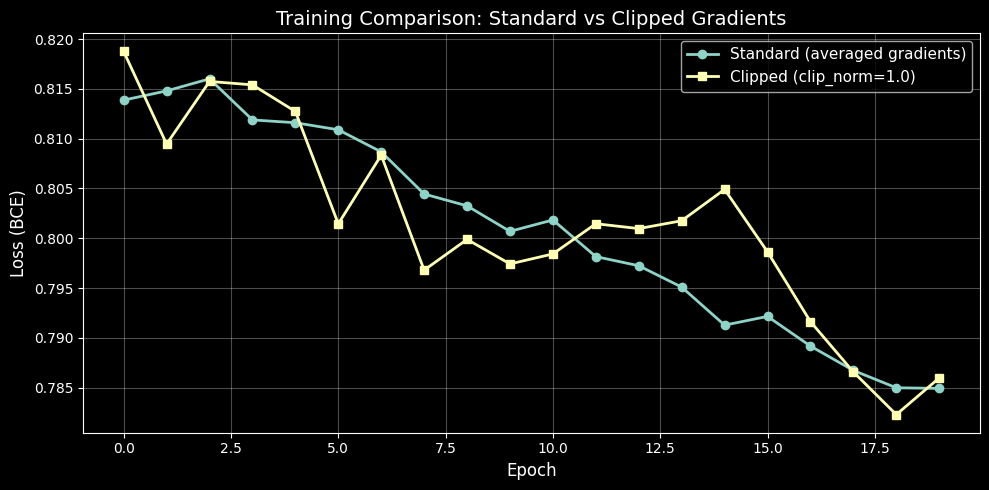

Final loss (standard): 0.7849
Final loss (clipped):  0.7860


In [40]:
# Plot comparison
plt.figure(figsize=(10, 5))
plt.plot(losses_standard, label="Standard (averaged gradients)", marker="o", linewidth=2)
plt.plot(losses_clipped, label="Clipped (clip_norm=1.0)", marker="s", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (BCE)", fontsize=12)
plt.title("Training Comparison: Standard vs Clipped Gradients", fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final loss (standard): {losses_standard[-1]:.4f}")
print(f"Final loss (clipped):  {losses_clipped[-1]:.4f}")

---

## Summary

### What We Learned

1. **Standard PyTorch**: Gradients are averaged across batch
   - Not suitable for per-example gradient clipping

2. **Per-sample gradients**: Needed for gradient clipping in DP-SGD
   - Naive approach: Loop over examples (slow)
   - Efficient approach: `grad` + `vmap` (fast)

3. **Functional transformations**: `torch.func` for efficient operations
   - `grad(f)`: Computes gradients
   - `vmap(f)`: Vectorizes over batch dimension
   - `make_functional()`: Converts `nn.Module` to functional form

4. **`clipped_grad()`**: Opaque's convenience wrapper
   - Handles `grad` + `vmap` + clipping + summing
   - Clean, composable API
   - Ready for DP-SGD (just add noise!)

### Key Takeaways

**Gradient clipping workflow**:
```python
# 1. Convert model to functional
fmodel, params = make_functional(model)

# 2. Define per-example loss
def loss_single(params, example):
    x, y = example
    return loss(fmodel(params, x), y)

# 3. Create clipped gradient function (returns fn + state)
clipped_grad_fn, clip_state = clipped_grad(
    loss_single,
    argnums=0,
    batch_argnums=1,
    l2_clip_norm=1.0,
)

# 4. Use in training loop (pass state=)
grads, clip_state = clipped_grad_fn(params, (X_batch, y_batch), state=clip_state)
```

### What's Next?

**We have NOT covered differential privacy yet!** Why?

- DP-SGD = **gradient clipping + noise injection**
- We've implemented clipping (Stage 1 \u2705)
- Noise injection coming in Stage 2
- **Future Tutorials** will cover complete DP-SGD with privacy accounting

**For now**, you can:
- Use `clipped_grad()` for **gradient norm regularization**
- Experiment with different clip norms
- Try different architectures (CNNs, Transformers)